# Epoch Spring Camp 2026 - Take Home Task 3

In this task, you will build and compare two recommender system models:

- **Matrix Factorization (MF)** using a dot product of embeddings  
- **Neural Collaborative Filtering (MLP-based)** using a multi-layer perceptron  

You are provided with:
- Preprocessed interaction data
- Evaluation pipeline

You are expected to implement:
- Negative sampling
- Model architectures
- Training loop

---

The purpose of this task is to understand how neural networks can model user–item interactions beyond simple similarity.

## Imports

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import random

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display


## Loading Data

We begin by loading the interaction data.

In [2]:
df = pd.read_csv("interactions.csv")  # columns: user_id, movie_id

print("Num users:", df['user_id'].nunique())
print("Num items:", df['item_id'].nunique())
print("Num interactions:", len(df))

df.head()

Num users: 942
Num items: 1447
Num interactions: 55375


,user_id,item_id
0,0,0
1,1,1
2,2,2
3,3,3
4,4,4


Each row represents a **positive interaction** (implicit feedback).

## Train / Test Split

We split the data into training and testing sets.

The model will learn from the training data and be evaluated on unseen interactions in the test set.

In [3]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

## Negative Sampling

The dataset only contains **positive interactions** (user interacted with item).

However, to train a model, we also need **negative examples** (user did not interact with item).

---

### Why do we need this?

We treat recommendation as a **binary classification problem**:

- Positive interaction → label = 1  
- No interaction → label = 0  

Since we don’t have explicit negatives, we **sample them**.

---

### Your Task

For each `(user, item)` interaction:
- Keep it as a **positive sample (label = 1)**
- Sample one or more items the user has **not interacted with**
  - Add them as **negative samples (label = 0)**

---

### Hints

- You can randomly sample items
- Make sure sampled negatives are **not already in the dataset**
- You may use a `set` of `(user, item)` pairs for fast lookup

---

Implement a function:
`sample_negatives(df, num_neg=1)`
that returns a dataframe with columns:
`[user, item, label]`

In [4]:
def sample_negatives(df, num_neg=1):
    data = {
        "user": [],
        "item": [],
        "label": []
    }

    unique_items = df['item_id'].unique()

    for int in df.itertuples():
        data["user"].append(int.user_id)
        data["item"].append(int.item_id)
        data["label"].append(1)

        user_pos = set(df[df['user_id'] == int.user_id]['item_id'])
        user_negs = [item for item in unique_items if item not in user_pos]
        if len(user_negs) < num_neg:
            continue  # Skip if not enough negatives available

        data["user"].extend([int.user_id] * num_neg)
        data["item"].extend(random.sample(user_negs, k=num_neg))
        data["label"].extend([0] * num_neg)

    return pd.DataFrame(data)

## PyTorch Dataset

We now wrap our processed data into a PyTorch `Dataset`.

This allows us to:
- Access individual samples as `(user, item, label)`
- Easily plug into a `DataLoader` for batching

You do not need to modify this part.

In [5]:
class InteractionDataset(Dataset):
    def __init__(self, df):
        self.users = torch.tensor(df['user'].values)
        self.items = torch.tensor(df['item'].values)
        self.labels = torch.tensor(df['label'].values).float()

    def __len__(self):
        return len(self.users)

    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.labels[idx]

## DataLoader

The `DataLoader` will:
- Batch the data
- Shuffle the training data
- Feed it to the model during training

In [6]:
train_data = sample_negatives(train_df, num_neg=20)

train_loader = DataLoader(InteractionDataset(train_data), batch_size=256, shuffle=True)

Why are we sampling negatives only for the training data?

We do this because our data currently only has positive labels (1). We can determine the negative labels (0) by checking if a user-item pair does **NOT** exist in the dataset.

## Quick Exploration

Before building models, take a moment to explore the data.

Try to understand:
- How many interactions each user has
- How popular certain items are

This can give intuition about the dataset.

In [7]:
# Interactions per user
user_counts = df['user_id'].value_counts()
print(user_counts.describe())

# Interactions per item
item_counts = df['item_id'].value_counts()
print(item_counts.describe())

train_data.describe()

count    942.000000
mean      58.784501
std       54.696664
min        3.000000
25%       19.000000
50%       39.500000
75%       80.750000
max      378.000000
Name: count, dtype: float64
count    1447.000000
mean       38.268832
std        57.956847
min         1.000000
25%         3.000000
50%        13.000000
75%        47.500000
max       501.000000
Name: count, dtype: float64


,user,item,label
count,930300.000000,930300.000000,930300.000000
mean,431.634876,713.141124,0.047619
std,284.522872,411.921462,0.212959
min,0.000000,0.000000,0.000000
25%,150.000000,358.000000,0.000000
50%,434.000000,712.000000,0.000000
75%,669.000000,1067.000000,0.000000
max,941.000000,1446.000000,1.000000


## Baseline Model: Matrix Factorization (MF)

We represent:
- Each **user** as a vector (embedding)
- Each **item** as a vector (embedding)

To predict interaction:
- Compute the **dot product** between user and item embeddings

This gives a **score** indicating how likely the user is to interact with the item.

---

### Your Task

Implement a model that:
1. Learns user and item embeddings
2. Computes their dot product as the output score

In [8]:
class MF(nn.Module):
    def __init__(self, num_users, num_items, emb_dim):
        super().__init__()

        self.user_emb = nn.Embedding(num_users, emb_dim)  # user_id -> user_emb, ie if user_id: (n, 1) -> (n, emb_dim)
        self.item_emb = nn.Embedding(num_items, emb_dim)  # item_id -> item_emb, ie if item_id: (n, 1) -> (n, emb_dim)

    def forward(self, user, item):
        return torch.sum(self.user_emb(user) * self.item_emb(item), dim=1)

## Training the MF Model

Now train your Matrix Factorization model.

You will need to:
- Define a loss function
- Define an optimizer
- Iterate over the DataLoader
- Update model parameters

---

### Hints

- Use **Binary Cross Entropy loss**
- Apply **sigmoid** to model outputs if needed
- Typical steps:
  - forward pass
  - compute loss
  - backward pass
  - optimizer step

In [9]:
def train(model: nn.Module, dataloader: DataLoader, epochs: int):
    model = model.to('cuda' if torch.cuda.is_available() else 'cpu')
    model.train()

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.BCEWithLogitsLoss()

    losses = []  # track loss per epoch

    for epoch in range(epochs):
        total_loss = 0

        for user, item, label in dataloader:
            user = user.to('cuda' if torch.cuda.is_available() else 'cpu')
            item = item.to('cuda' if torch.cuda.is_available() else 'cpu')
            label = label.to('cuda' if torch.cuda.is_available() else 'cpu')

            fwd = model.forward(user, item)
            loss = loss_fn(fwd, label)
            total_loss += loss.item()
    
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

        losses.append(total_loss)
        print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

    return losses

## Evaluation (Hit@K)

We evaluate the model using a ranking-based metric.

For each user:
- Take one positive item
- Sample multiple negative items
- Rank all items using the model
- Check if the positive item is in the top-K

This is called **Hit@K**.

In [10]:
def hit_at_k(model, test_df, full_df, K=10, num_neg=100):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    model.to(device)

    hits = 0
    total = len(df) # We evaluate every positive interaction in the test set

    # Map interactions for quick lookup
    interacted_items = full_df.groupby('user_id')['item_id'].apply(set).to_dict()
    all_items = full_df['item_id'].unique()

    with torch.no_grad(): # Disable gradient calculation for speed/memory
        for _, row in df.iterrows():
            print("Hit@K Progress: {:.2f}%".format(_ / total * 100), end='\r')
            u = int(row['user_id'])
            pos_item = int(row['item_id'])

            # 1. Sample Negatives
            negatives = []
            while len(negatives) < num_neg:
                neg_item = np.random.choice(all_items)
                if neg_item not in interacted_items.get(u, set()):
                    negatives.append(neg_item)

            # 2. Prepare Tensors
            # We need a list of the 1 positive + 100 negatives
            item_list = [pos_item] + negatives
            user_tensor = torch.tensor([u] * (num_neg + 1)).to(device)
            item_tensor = torch.tensor(item_list).to(device)

            # 3. Get Scores
            scores = model(user_tensor, item_tensor)

            # 4. Rank and Check Hit
            # We want to see if the item at index 0 (the positive) is in the top K
            # torch.topk returns values and indices of the highest scores
            _, top_indices = torch.topk(scores, K)

            top_indices = top_indices.cpu().numpy()
            if 0 in top_indices:
                hits += 1

        return hits / total

Epoch 1, Loss: 38909.8456
Epoch 2, Loss: 16438.8122
Epoch 3, Loss: 5721.6153
Epoch 4, Loss: 2378.1599
Epoch 5, Loss: 893.9373
Epoch 6, Loss: 243.5705
Epoch 7, Loss: 33.4644
Epoch 8, Loss: 1.8363
Epoch 9, Loss: 0.2661
Epoch 10, Loss: 0.0733
Epoch 11, Loss: 0.0199
Epoch 12, Loss: 0.0050
Epoch 13, Loss: 0.0012
Epoch 14, Loss: 0.0003
Epoch 15, Loss: 0.0001
Epoch 16, Loss: 0.0001
Epoch 17, Loss: 0.0000
Epoch 18, Loss: 0.0000
Epoch 19, Loss: 0.0000
Epoch 20, Loss: 0.0000
Epoch 21, Loss: 0.0000
Epoch 22, Loss: 0.0000
Epoch 23, Loss: 0.0000
Epoch 24, Loss: 0.0000
Epoch 25, Loss: 0.0000
Epoch 26, Loss: 0.0000
Epoch 27, Loss: 0.0000
Epoch 28, Loss: 0.0000
Epoch 29, Loss: 0.0000
Epoch 30, Loss: 0.0000
Epoch 31, Loss: 0.0000
Epoch 32, Loss: 0.0000
Epoch 33, Loss: 0.0000
Epoch 34, Loss: 0.0000
Epoch 35, Loss: 0.0000
Epoch 36, Loss: 0.0000
Epoch 37, Loss: 0.0000
Epoch 38, Loss: 0.0000
Epoch 39, Loss: 0.0000
Epoch 40, Loss: 0.0000
Hit@K Progress: 100.00%
Hit@10: 0.8109255079006772


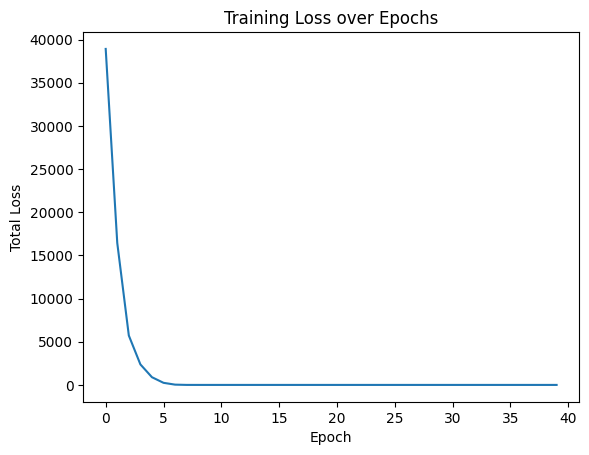

In [11]:
model = MF(num_users=df['user_id'].nunique(), num_items=df['item_id'].nunique(), emb_dim=1024)
losses = train(model, train_loader, epochs=40)
hit_rate = hit_at_k(model, test_df, df, K=10, num_neg=100)
print(f"\nHit@10: {hit_rate}")

# Plotting losses
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Total Loss')
plt.title('Training Loss over Epochs')
plt.show()

If your score is low, try playing with the hyperparameters before moving on! Try sampling more negatives, or playing with the embedding dimensions.

Conversely, if your score is high, play with the values of K or number of negatives in evaluation (dec K, inc negatives).

## Neural Model: MLP-Based Recommender

Instead of using a dot product, we can learn a more flexible interaction function using a neural network.

Approach:
- Learn user and item embeddings
- **Concatenate** them
- Pass through a **Multi-Layer Perceptron (MLP)**

This allows the model to capture more complex relationships than simple similarity.

---

### Your Task

Implement a model that:
1. Learns user and item embeddings
2. Concatenates them
3. Passes them through an MLP to produce a score

The choice of activation functions is upto you.

In [12]:
class MLP(nn.Module):
    def __init__(self, num_users, num_items, emb_dim):
        super().__init__()

        self.user_emb = nn.Embedding(num_users, emb_dim)
        self.item_emb = nn.Embedding(num_items, emb_dim)
        self.mlp = nn.Sequential(
            nn.Linear(emb_dim * 2, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 1)
        )

    def forward(self, user, item):
        u = self.user_emb(user)
        i = self.item_emb(item)
        conc = torch.cat([u, i], dim=1)
        return self.mlp(conc).squeeze()

## Train and Evaluate the MLP Model

Repeat the same steps as before:
- Train the model
- Evaluate on the test set

Compare its performance with the MF model.

In [13]:
MLP_model = MLP(num_users=df['user_id'].nunique(), num_items=df['item_id'].nunique(), emb_dim=128)
losses = train(MLP_model, train_loader, epochs=200)
hit_rate = hit_at_k(MLP_model, test_df, df, K=10, num_neg=100)
print(f"\nHit@10: {hit_rate:.4f}")

Epoch 1, Loss: 580.6773
Epoch 2, Loss: 548.6716
Epoch 3, Loss: 532.4371
Epoch 4, Loss: 498.0299
Epoch 5, Loss: 459.7283
Epoch 6, Loss: 424.1212
Epoch 7, Loss: 386.0433
Epoch 8, Loss: 347.3476
Epoch 9, Loss: 310.0874
Epoch 10, Loss: 276.0558
Epoch 11, Loss: 244.6991
Epoch 12, Loss: 216.9239
Epoch 13, Loss: 191.2353
Epoch 14, Loss: 169.7369
Epoch 15, Loss: 150.3416
Epoch 16, Loss: 134.0997
Epoch 17, Loss: 121.0228
Epoch 18, Loss: 107.8145
Epoch 19, Loss: 96.5592
Epoch 20, Loss: 86.3899
Epoch 21, Loss: 80.0714
Epoch 22, Loss: 71.8406
Epoch 23, Loss: 66.3953
Epoch 24, Loss: 59.9006
Epoch 25, Loss: 57.0156
Epoch 26, Loss: 53.1815
Epoch 27, Loss: 48.1202
Epoch 28, Loss: 46.0838
Epoch 29, Loss: 43.3127
Epoch 30, Loss: 41.1471
Epoch 31, Loss: 38.2769
Epoch 32, Loss: 37.4305
Epoch 33, Loss: 35.4841
Epoch 34, Loss: 33.7461
Epoch 35, Loss: 32.6216
Epoch 36, Loss: 30.9555
Epoch 37, Loss: 30.0137
Epoch 38, Loss: 28.9162
Epoch 39, Loss: 28.1524
Epoch 40, Loss: 26.4677
Epoch 41, Loss: 25.6525
Epoch 4

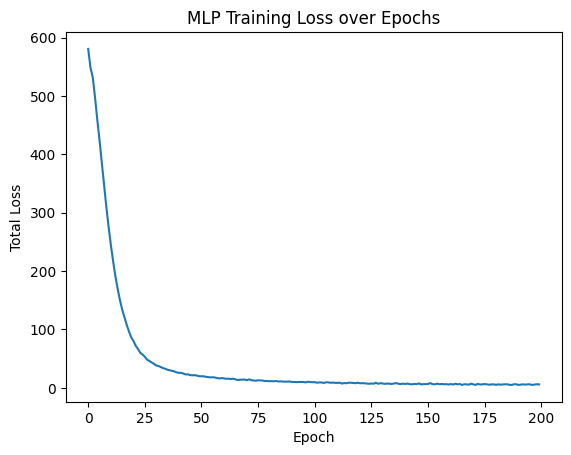

In [14]:
# Plotting losses

plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Total Loss')
plt.title('MLP Training Loss over Epochs')
plt.show()

## Comparison & Analysis

You have now implemented:
- Matrix Factorization (MF)
- MLP-based recommender

---

### Compare the Models

- What score did each model achieve?
- Which model performed better?

---

### Think & Reflect

- Why might the MLP model outperform MF?
- In what cases might MF perform just as well or better?
- How does embedding size affect performance?
- Did you observe any signs of overfitting?

---

### Some Experiments

If you want to explore further:
- Try different embedding dimensions
- Change number of MLP layers
- Try different activation functions

---

Clearly the MLP model did better than MF, likely because it can capture more complex interactions between users and items. The MF model relies on a simple dot product, which may not be sufficient to model the nuances in user preferences. The MLP, on the other hand, can learn non-linear relationships, allowing it to better fit the data and achieve a higher Hit@10 score.

In some sense, a MF model is a special case of an MLP where the interaction function is restricted to a dot product. By using an MLP, we allow the model to learn more complex patterns in the data, which can lead to better recommendations.

## Bonus Task: Neural Collaborative Filtering (NCF)

In this task, you implemented:
- Matrix Factorization (MF)
- MLP-based recommender

The paper [Neural Collaborative Filtering](https://arxiv.org/pdf/1708.05031) proposes combining both ideas.

---

### Idea

- MF captures **linear interactions**
- MLP captures **nonlinear interactions**

NCF combines both by:
1. Computing MF output
2. Computing MLP output
3. Combining them into a final prediction

---

### Your Task

Design a model that:
- Uses both MF and MLP components
- Combines their outputs
- Trains end-to-end

---

### Hints

- You can:
  - Concatenate MF and MLP representations
  - Or combine their final scores
- Think about:
  - Should embeddings be shared or separate?
  - How to balance both components?

---

Does combining both approaches improve performance over MF and MLP individually?

In [15]:
class NCF(nn.Module):
    def __init__(self, num_users, num_items, emb_dim):
        super().__init__()

        self.user_emb = nn.Embedding(num_users, emb_dim)
        self.item_emb = nn.Embedding(num_items, emb_dim)
        self.mlp = nn.Sequential(
            nn.Linear(emb_dim * 2, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 1)
        )

        self.seq2 = nn.Sequential(
            nn.Linear(2, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 1)
        )

    def forward(self, user, item):
        mlp_out = torch.sum(self.user_emb(user) * self.item_emb(item), dim=1)
        u = self.user_emb(user)
        i = self.item_emb(item)
        conc = torch.cat([u, i], dim=1)
        mfp_out = self.mlp(conc).squeeze()
        c2 = torch.cat([mlp_out.unsqueeze(1), mfp_out.unsqueeze(1)], dim=1)

        return self.seq2(c2).squeeze()

In [16]:
NCF_model = NCF(num_users=df['user_id'].nunique(), num_items=df['item_id'].nunique(), emb_dim=128)
losses = train(NCF_model, train_loader, epochs=200)
hit_rate = hit_at_k(NCF_model, test_df, df, K=10, num_neg=100)
print(f"\nHit@10: {hit_rate:.4f}")

Epoch 1, Loss: 588.4091
Epoch 2, Loss: 548.6890
Epoch 3, Loss: 527.0258
Epoch 4, Loss: 479.6234
Epoch 5, Loss: 416.1081
Epoch 6, Loss: 359.1553
Epoch 7, Loss: 311.3548
Epoch 8, Loss: 274.0860
Epoch 9, Loss: 238.5832
Epoch 10, Loss: 210.2442
Epoch 11, Loss: 183.3499
Epoch 12, Loss: 159.4550
Epoch 13, Loss: 136.9263
Epoch 14, Loss: 116.8753
Epoch 15, Loss: 100.9590
Epoch 16, Loss: 89.3072
Epoch 17, Loss: 79.3676
Epoch 18, Loss: 74.4592
Epoch 19, Loss: 65.8981
Epoch 20, Loss: 60.7204
Epoch 21, Loss: 57.0559
Epoch 22, Loss: 53.1025
Epoch 23, Loss: 49.1562
Epoch 24, Loss: 46.0628
Epoch 25, Loss: 43.8870
Epoch 26, Loss: 41.8399
Epoch 27, Loss: 39.0665
Epoch 28, Loss: 38.8236
Epoch 29, Loss: 36.2871
Epoch 30, Loss: 35.1084
Epoch 31, Loss: 33.6353
Epoch 32, Loss: 31.5464
Epoch 33, Loss: 31.2531
Epoch 34, Loss: 29.4317
Epoch 35, Loss: 28.8347
Epoch 36, Loss: 28.0099
Epoch 37, Loss: 26.8106
Epoch 38, Loss: 27.5609
Epoch 39, Loss: 25.7713
Epoch 40, Loss: 23.7597
Epoch 41, Loss: 23.0739
Epoch 42, 

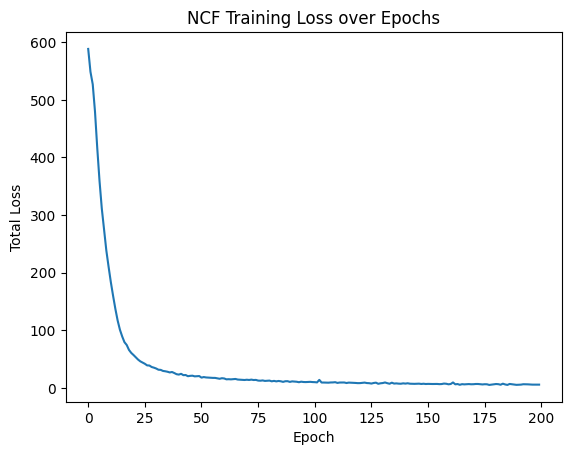

In [17]:
# Plotting losses

plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Total Loss')
plt.title('NCF Training Loss over Epochs')
plt.show()